# Data exploration

This notebook provides a simple, hands-on exploration of the example data included in this repository. It includes lab spectra, hyperspectral image subsets, a vegetation/shadow mask, and example Random Forest model predictions (at the pixel level).

This notebook is intended for exploratory use only and does not reproduce the full formal analysis presented in the paper.

For details on the complete methodology, model development, validation, and interpretation of results, please refer to:

UAS Ecophysiology: Imaging spectroscopy can map canopy water potential in a diverse forest ecosystem
DOI: https://doi.org/10.1016/j.rse.2026.115532

In [9]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import spectral

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

repo_root = Path.cwd()
if repo_root.name == "Scripts":
    repo_root = repo_root.parent

lab_dir = repo_root / "Data" / "Lab_spectra"
image_dir = repo_root / "Data" / "Example_imagery"
model_dir = repo_root / "Data" / "Model_pkls"

spectra_files = sorted(lab_dir.glob("*_spectra_DF.csv"))
[f.name for f in spectra_files]

['A_verticillata_spectra_DF.csv',
 'C_rhomboidea_AND_M_pustulata__spectra_DF.csv',
 'C_rhomboidea_spectra_DF.csv',
 'E_pulchella_spectra_DF.csv',
 'E_viminalis_spectra_DF.csv',
 'M_pustulata_spectra_DF.csv']

## 1. Plot one spectra dataframe by water potential

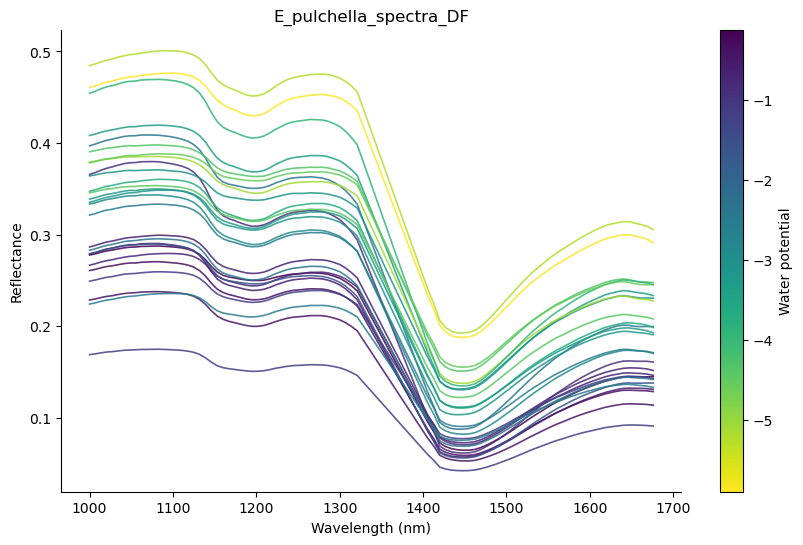

In [3]:
def wavelengths_from_columns(columns):
    return np.array([float(str(col).replace("B_", "")) for col in columns])


def plot_spectra(df, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 6))

    y = df.iloc[:, 0]
    X = df.iloc[:, 1:]
    wavelengths = wavelengths_from_columns(X.columns)
    norm = plt.Normalize(y.min(), y.max())
    cmap = plt.cm.viridis_r

    for i in range(len(df)):
        ax.plot(wavelengths, X.iloc[i], color=cmap(norm(y.iloc[i])), linewidth=1.2, alpha=0.85)

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label("Water potential")

    ax.set_title(title)
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Reflectance")
    return ax


one_spectra_path = lab_dir / "E_pulchella_spectra_DF.csv"
one_df = pd.read_csv(one_spectra_path)

plot_spectra(one_df, one_spectra_path.stem)
plt.show()

## 2. Plot all spectra dataframes

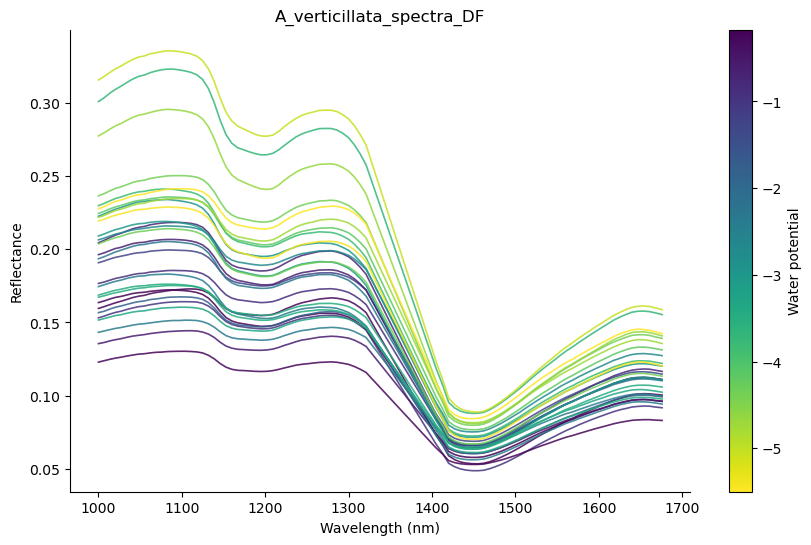

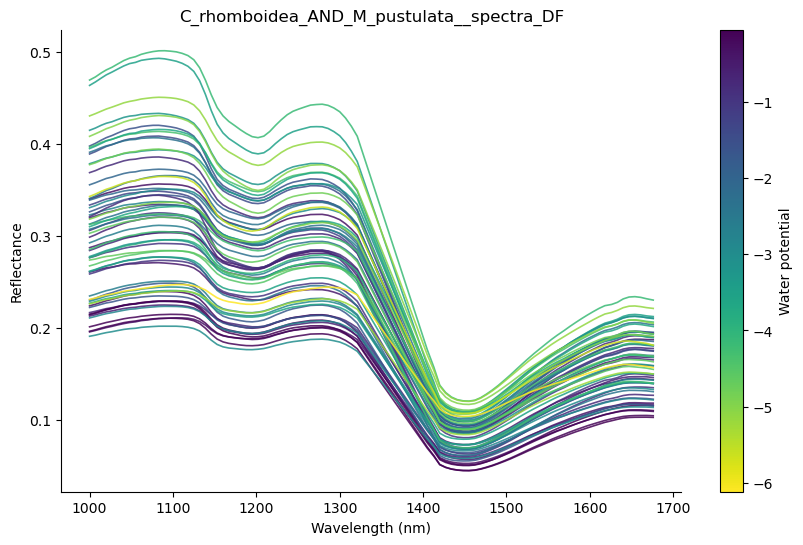

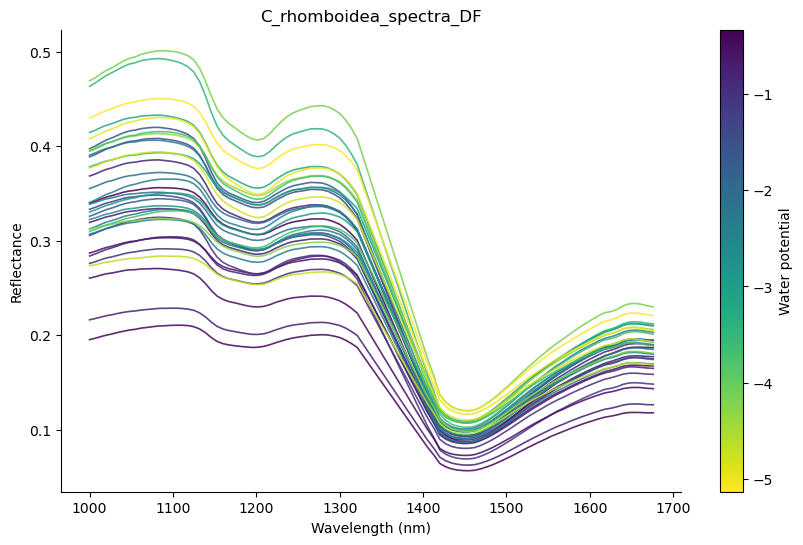

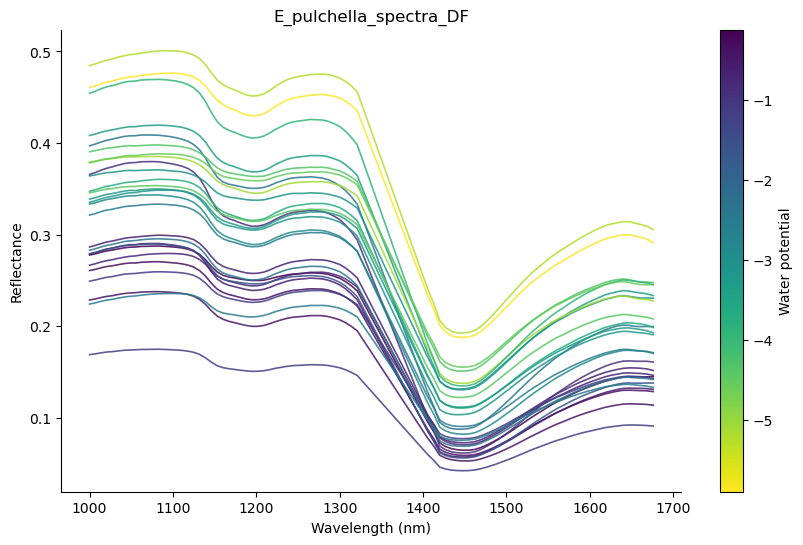

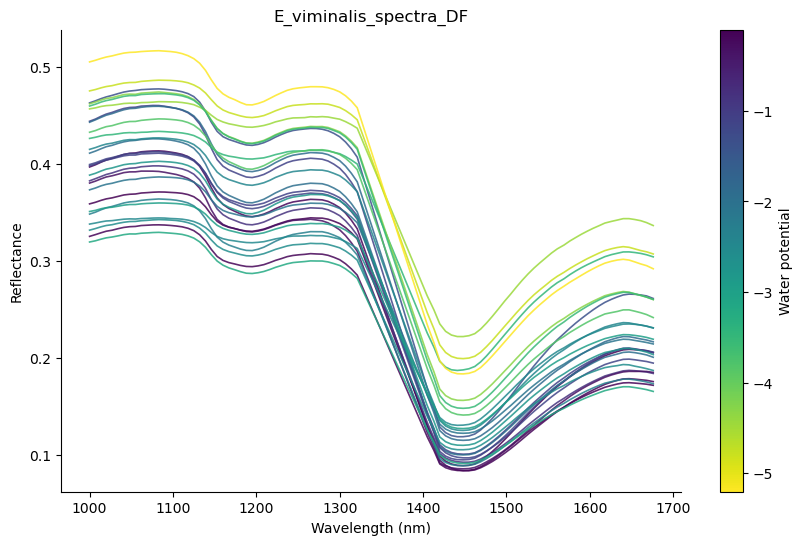

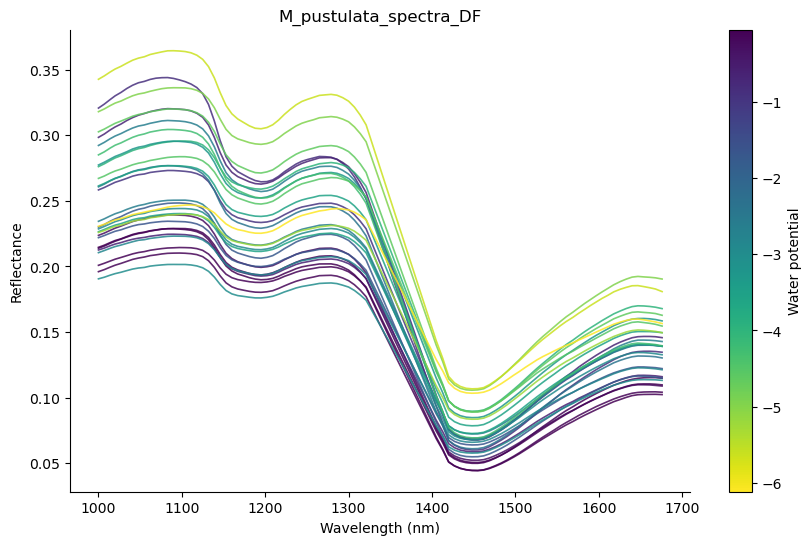

In [4]:
for path in spectra_files:
    df = pd.read_csv(path)
    plot_spectra(df, path.stem)
    plt.show()

## 3. Load and plot the example imagery subsets

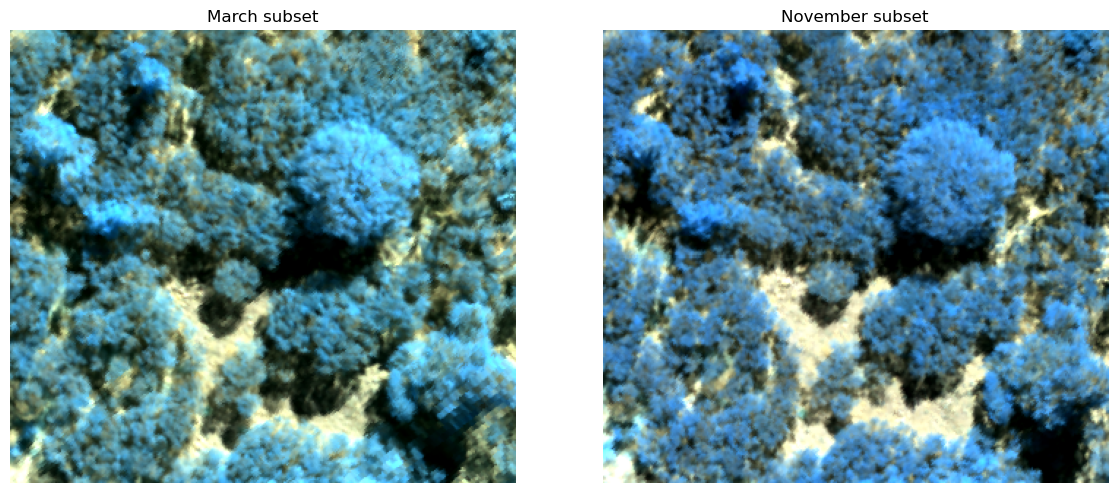

In [5]:
march_hdr = image_dir / "20240305_FX17_Swansea_subset.hdr"
november_hdr = image_dir / "20241105_FX17_Swansea_subset.hdr"
mask_hdr = image_dir / "veg_shadow_mask.hdr"


def load_envi_array(hdr_path):
    img = spectral.open_image(str(hdr_path))
    return np.asarray(img.load()), img


def scale_reflectance(data):
    data = data.astype(float)
    max_value = np.nanmax(data)
    if max_value > 1000:
        return data / 10000.0
    if max_value > 1.5:
        return data / 100.0
    return data


def rgb_from_cube(data, bands=(80, 49, 11)):
    rgb = scale_reflectance(data[:, :, list(bands)])
    low, high = np.nanpercentile(rgb, [2, 98])
    rgb = np.clip((rgb - low) / (high - low), 0, 1)
    return rgb


march_data, march_img = load_envi_array(march_hdr)
november_data, november_img = load_envi_array(november_hdr)

march_rgb = rgb_from_cube(march_data)
november_rgb = rgb_from_cube(november_data)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(march_rgb)
axes[0].set_title("March subset")
axes[1].imshow(november_rgb)
axes[1].set_title("November subset")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 4. Plot the vegetation/shadow mask over the March subset

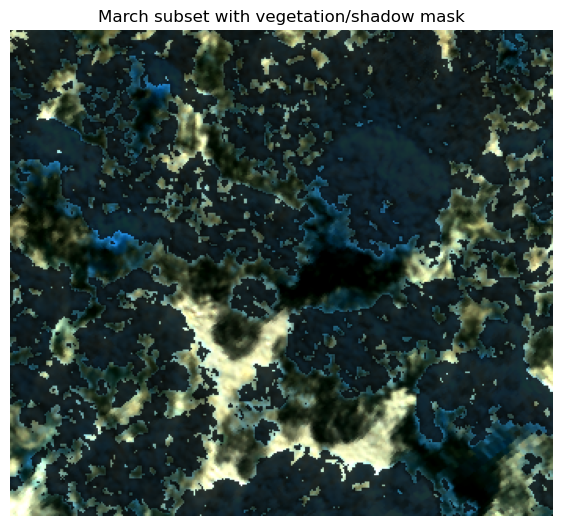

In [6]:
mask_data, mask_img = load_envi_array(mask_hdr)
mask = np.squeeze(mask_data) == 1

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(march_rgb)
ax.imshow(np.ma.masked_where(~mask, mask), cmap="gray", alpha=0.8)
ax.set_title("March subset with vegetation/shadow mask")
ax.axis("off")
plt.show()

## 5. Apply one RF model to masked imagery only

### NOTE:

This step applies a selected Random Forest model directly to the masked hyperspectral imagery at the per-pixel level. This provides a useful visual example of how model predictions can be spatially applied across an image subset.

However, this is intended for visualisation and data exploration only. In the paper, model predictions were applied using the species-labelled segment workflow, rather than by applying a single model across all masked pixels. As such, the outputs shown here should not be interpreted as reproducing the formal results presented in the study.

In [21]:
model_path = model_dir / "M_pustulata_rf_model.pkl"

with open(model_path, "rb") as f:
    rf_model = pickle.load(f)

model_features = list(getattr(rf_model, "feature_names_in_", one_df.columns[1:]))
print(f"Loaded model: {model_path.name}")
print(f"Model expects {len(model_features)} features")

if len(model_features) != march_data.shape[2]:
    raise ValueError(
        f"Model expects {len(model_features)} features, "
        f"but the imagery has {march_data.shape[2]} bands."
    )


def crop_to_common_shape(data, mask):
    rows = min(data.shape[0], mask.shape[0])
    cols = min(data.shape[1], mask.shape[1])
    return data[:rows, :cols, :], mask[:rows, :cols]


def predict_image_then_mask(data, mask, model, feature_names):
    data_crop, mask_crop = crop_to_common_shape(data, mask)
    scaled = scale_reflectance(data_crop)
    valid_pixels = np.all(np.isfinite(scaled), axis=2) & np.all(scaled > 0, axis=2)

    full_prediction_map = np.full(mask_crop.shape, np.nan, dtype=float)
    pixel_spectra = pd.DataFrame(scaled[valid_pixels], columns=feature_names)
    full_prediction_map[valid_pixels] = model.predict(pixel_spectra)

    masked_prediction_map = full_prediction_map.copy()
    masked_prediction_map[~mask_crop] = np.nan
    return full_prediction_map, masked_prediction_map, scaled, valid_pixels


march_all_predictions, march_predictions, march_scaled, march_valid = predict_image_then_mask(
    march_data, mask, rf_model, model_features
)
november_all_predictions, november_predictions, november_scaled, november_valid = predict_image_then_mask(
    november_data, mask, rf_model, model_features
)

def print_prediction_summary(name, predictions):
    values = predictions[np.isfinite(predictions)]
    if values.size == 0:
        print(f"{name}: no valid masked pixels")
        return
    print(
        f"{name}: {values.size} pixels, "
        f"min={values.min():.4f}, mean={values.mean():.4f}, "
        f"max={values.max():.4f}, std={values.std():.4f}, "
        f"unique rounded={np.unique(np.round(values, 4)).size}"
    )


def print_spectra_summary(name, scaled, valid_pixels):
    values = scaled[valid_pixels]
    print(
        f"{name} scaled spectra: "
        f"min={np.nanmin(values):.4f}, "
        f"median={np.nanmedian(values):.4f}, "
        f"max={np.nanmax(values):.4f}"
    )


lab_values = one_df.iloc[:, 1:].to_numpy()
print(
    "Lab spectra: "
    f"min={np.nanmin(lab_values):.4f}, "
    f"median={np.nanmedian(lab_values):.4f}, "
    f"max={np.nanmax(lab_values):.4f}"
)

print_prediction_summary("March masked", march_predictions)
print_prediction_summary("November masked", november_predictions)

c:\Users\rhaynes0\AppData\Local\miniforge3\envs\Nature-scan\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.5.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\rhaynes0\AppData\Local\miniforge3\envs\Nature-scan\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.5.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Loaded model: M_pustulata_rf_model.pkl
Model expects 97 features
Lab spectra: min=0.0420, median=0.2351, max=0.5008
March masked: 60600 pixels, min=-5.5343, mean=-4.0661, max=-0.6946, std=1.2383, unique rounded=27183
November masked: 60600 pixels, min=-5.5389, mean=-3.3555, max=-0.2394, std=1.5214, unique rounded=32201


## 6. Plot RF predictions over both subsets

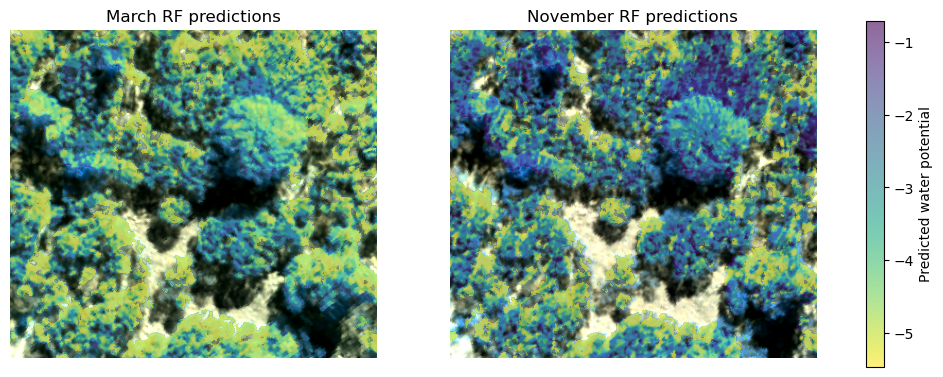

In [25]:
def crop_rgb_to_prediction(rgb, predictions):
    return rgb[:predictions.shape[0], :predictions.shape[1], :]


prediction_values = np.concatenate([
    march_predictions[np.isfinite(march_predictions)],
    november_predictions[np.isfinite(november_predictions)],
])
vmin, vmax = np.nanpercentile(prediction_values, [2, 98])
if np.isclose(vmin, vmax):
    vmin, vmax = prediction_values.min(), prediction_values.max()
if np.isclose(vmin, vmax):
    vmin, vmax = vmin - 0.01, vmax + 0.01

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, rgb, preds, title in [
    (axes[0], march_rgb, march_predictions, "March RF predictions"),
    (axes[1], november_rgb, november_predictions, "November RF predictions"),
]:
    ax.imshow(crop_rgb_to_prediction(rgb, preds))
    im = ax.imshow(np.ma.masked_invalid(preds), cmap="viridis_r", vmin=vmin, vmax=vmax, alpha=0.6)
    ax.set_title(title)
    ax.axis("off")

cbar = fig.colorbar(im, ax=axes, shrink=0.9)
cbar.set_label("Predicted water potential")

plt.show()